In [1]:
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x, y = torch.load('MNIST\\MNIST\\processed\\training.pt')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18288\3523418150.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x, y = torch.load('MNIST\\MNIST\\processed\\training.pt')


Number is 4


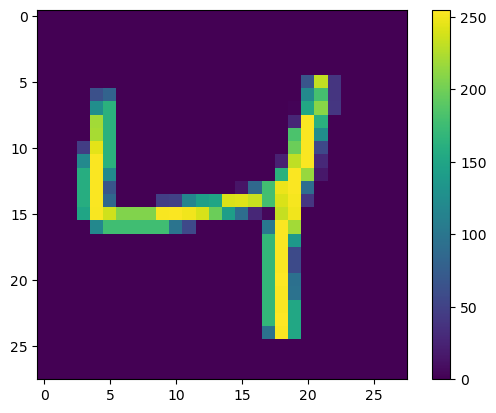

In [3]:
plt.imshow(x[2].numpy())
print(f'Number is {y[2].numpy()}')
plt.colorbar()
plt.show()

In [4]:
#One hot encoding the y values
y_new = F.one_hot(y, num_classes = 10)
y_new.shape

torch.Size([60000, 10])

In [5]:
# Turn the images into a vector(which will be of length 28*28 = 784)
x.view(-1, 28**2).shape

torch.Size([60000, 784])

In [6]:
class CTDataset(Dataset):
    def __init__(self, filepath):
        self.x, self.y = torch.load(filepath)
        self.x = self.x / 255.
        self.y = F.one_hot(self.y, num_classes=10).to(float)
    def __len__(self): 
        return self.x.shape[0]
    def __getitem__(self, ix): 
        return self.x[ix], self.y[ix]

In [7]:
train_ds = CTDataset('MNIST\\MNIST\\processed\\training.pt')
test_ds = CTDataset('MNIST\\MNIST\\processed\\test.pt')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18288\1729874014.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.x, self.y = torch.load(filepath)


In [8]:
len(train_ds)

60000

In [9]:
train_dl = DataLoader(train_ds, batch_size = 5)

In [10]:
for x, y in train_dl:
    print(x.shape)
    print(y.shape)
    break

torch.Size([5, 28, 28])
torch.Size([5, 10])


Since the batch size here is 5, and there are 60,000 images, the length of the dataloader object should be 12,000

In [12]:
len(train_dl)

12000

In [13]:
L = nn.CrossEntropyLoss()

In [14]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.Matrix1 = nn.Linear(28**2,100)
        self.Matrix2 = nn.Linear(100,50)
        self.Matrix3 = nn.Linear(50,10)
        self.R = nn.ReLU()
    def forward(self,x):
        x = x.view(-1,28**2)
        x = self.R(self.Matrix1(x))
        x = self.R(self.Matrix2(x))
        x = self.Matrix3(x)
        return x.squeeze()

In [15]:
f = MyNeuralNet()

In [16]:
def train_model(dl, f, n_epochs=20):
    # Optimization
    opt = SGD(f.parameters(), lr=0.01)
    L = nn.CrossEntropyLoss()

    # Train model
    losses = []
    epochs = []
    for epoch in range(n_epochs):
        print(f'Epoch {epoch}')
        N = len(dl)
        for i, (x, y) in enumerate(dl):
            # Update the weights of the network
            opt.zero_grad() 
            loss_value = L(f(x), y) 
            loss_value.backward() 
            opt.step() 
            # Store training data
            epochs.append(epoch+i/N)
            losses.append(loss_value.item())
    return np.array(epochs), np.array(losses)

In [17]:
epoch_data, loss_data = train_model(train_dl, f)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19


Text(0.5, 1.0, 'Cross Entropy(per batch)')

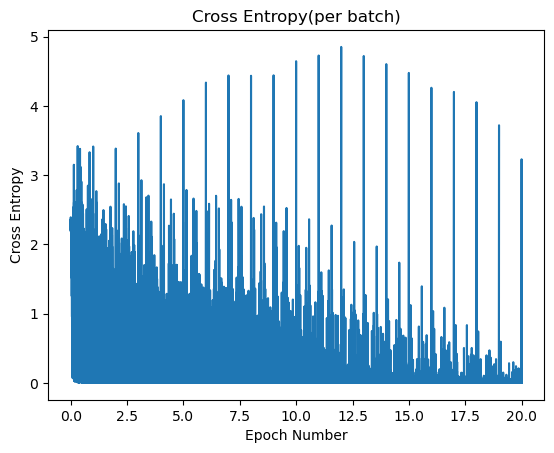

In [18]:
plt.plot(epoch_data, loss_data)
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entropy')
plt.title('Cross Entropy(per batch)')

In [19]:
epoch_data_avg = epoch_data.reshape(20, -1).mean(axis = 1)
loss_data_avg = loss_data.reshape(20, -1).mean(axis = 1)

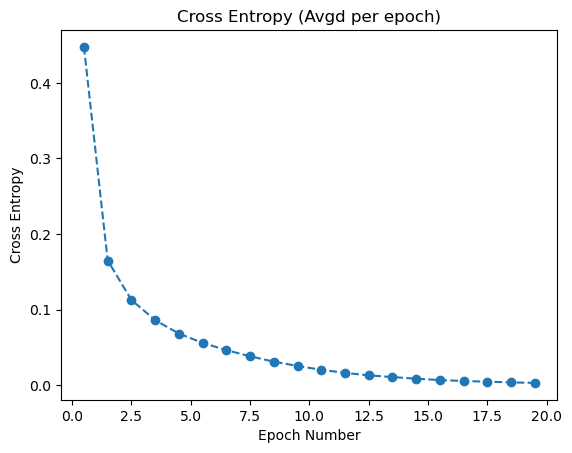

In [21]:
plt.plot(epoch_data_avg, loss_data_avg, 'o--')
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entropy')
plt.title('Cross Entropy (Avgd per epoch)')
plt.show()

In [22]:
y_sample = train_ds[0][1]
y_sample

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=torch.float64)

In [23]:
x_sample = train_ds[0][0]
yhat_sample = f(x_sample)
yhat_sample

tensor([-13.4891,  -3.4308,  -0.7696,  28.3052, -28.6494,  34.3043, -14.5084,
          0.3095,  -7.7002,   2.5385], grad_fn=<SqueezeBackward0>)

In [26]:
torch.argmax(yhat_sample)

tensor(5)

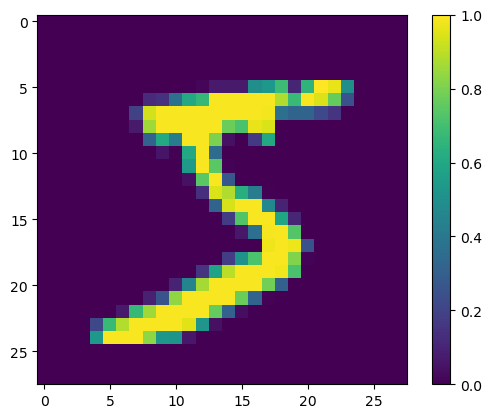

In [24]:
plt.imshow(train_ds[0][0])
plt.colorbar()